## Lyapunov 指数------初版·Benettin 算法（成功）

### QR

In [21]:
#修正 Gram-Schmidt 算法（Modified Gram-Schmidt, MGS）
'''
每次只存储当前列，内存友好。

当矩阵接近奇异时可能丢失正交性，但一般够用
R 的对角线元素为正（因为取的是列向量的范数）
'''
import numpy as np

def qr_decomp_mgs(A):
    """
    对矩阵 A (m x n, m >= n) 进行 QR 分解 (经济型)。
    返回 Q (m x n) 和 R (n x n)，满足 A = Q @ R。
    R 是上三角矩阵，Q 的列正交（Q^T Q = I）。
    """
    A = np.array(A, dtype=float)
    m, n = A.shape
    # 复制 A 作为工作矩阵
    V = A.copy()
    Q = np.zeros((m, n))
    R = np.zeros((n, n))

    for j in range(n):
        # 提取第 j 列向量
        v = V[:, j]
        # 计算 R[j,j] = ||v||
        R[j, j] = np.linalg.norm(v)
        if R[j, j] < 1e-12:
            # 列线性相关，设置 Q[:,j] 为零向量（或随机）
            Q[:, j] = 0.0
        else:
            Q[:, j] = v / R[j, j]
        # 更新剩余列：减去已正交化的分量
        for k in range(j+1, n):
            R[j, k] = np.dot(Q[:, j], V[:, k])
            V[:, k] -= R[j, k] * Q[:, j]
    return Q, R

In [22]:
# 使用 MGS
Q = np.array([
    [1.0, 2.0, 3.0, 4.0],
    [2.0, 3.0, 4.0, 5.0],
    [3.0, 4.0, 5.0, 6.0],
    [4.0, 5.0, 6.0, 7.0]
], dtype=float)
Q_mat, R_mat = qr_decomp_mgs(Q)   # Q_mat 为 4x4，R_mat 为 4x4 上三角
diag_R = np.diag(R_mat)
# 记录 ln(diag_R) 用于累加 Lyapunov 指数
print(Q_mat)
print(R_mat)
print(diag_R)

[[ 1.82574186e-01  8.16496581e-01  0.00000000e+00  0.00000000e+00]
 [ 3.65148372e-01  4.08248290e-01  0.00000000e+00  0.00000000e+00]
 [ 5.47722558e-01  5.43895982e-16  0.00000000e+00  0.00000000e+00]
 [ 7.30296743e-01 -4.08248290e-01  0.00000000e+00  0.00000000e+00]]
[[5.47722558e+00 7.30296743e+00 9.12870929e+00 1.09544512e+01]
 [0.00000000e+00 8.16496581e-01 1.63299316e+00 2.44948974e+00]
 [0.00000000e+00 0.00000000e+00 1.35064460e-15 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.98912807e-15]]
[5.47722558e+00 8.16496581e-01 1.35064460e-15 1.98912807e-15]


In [23]:
#Householder 变换算法
'''
R 的对角线元素可能为负（取决于反射向量的符号选择）
'''
def qr_decomp_householder(A):
    """
    使用 Householder 反射对 A (m x n) 进行 QR 分解。
    返回 Q (m x m) 和 R (m x n)，满足 A = Q @ R。
    其中 Q 是正交方阵，R 是上三角（下方全零）。
    """
    A = np.array(A, dtype=float)
    m, n = A.shape
    R = A.copy()
    Q = np.eye(m)   # 累积的 Q 矩阵

    for j in range(min(m, n)):
        # 构建 Householder 向量 u
        x = R[j:, j]
        norm_x = np.linalg.norm(x)
        if norm_x < 1e-12:
            continue
        alpha = -np.sign(x[0]) * norm_x   # 避免符号问题，也可用 -norm_x
        u = x.copy()
        u[0] -= alpha
        beta = np.dot(u, u)
        if beta < 1e-12:
            continue
        # 反射矩阵 H = I - 2 (u u^T)/beta
        # 更新 R 的子矩阵
        R[j:, j:] -= (2.0 / beta) * np.outer(u, u @ R[j:, j:])
        # 更新 Q 的左侧乘 H^T = H
        Q[:, j:] -= (2.0 / beta) * np.outer(Q[:, j:] @ u, u)
    return Q, R

In [24]:
Q_full, R_full = qr_decomp_householder(Q)   # Q_full 4x4, R_full 4x4 上三角
# 经济型 Q 可直接取前 n 列
Q_econ = Q_full[:, :4]   # 4x4
R_econ = R_full[:4, :4]  # 4x4 上三角
diag_R = np.diag(R_econ)

print(Q_full)
print(R_full)
print(diag_R)

[[-1.82574186e-01 -8.16496581e-01 -4.00087434e-01 -3.74072246e-01]
 [-3.65148372e-01 -4.08248290e-01  2.54632922e-01  7.96970561e-01]
 [-5.47722558e-01  3.60822483e-16  6.90996458e-01 -4.71724384e-01]
 [-7.30296743e-01  4.08248290e-01 -5.45541946e-01  4.88260693e-02]]
[[-5.47722558e+00 -7.30296743e+00 -9.12870929e+00 -1.09544512e+01]
 [ 0.00000000e+00 -8.16496581e-01 -1.63299316e+00 -2.44948974e+00]
 [ 0.00000000e+00  0.00000000e+00  7.77156117e-16  7.77156117e-16]
 [ 0.00000000e+00  0.00000000e+00 -2.22044605e-16 -4.44089210e-16]]
[-5.47722558e+00 -8.16496581e-01  7.77156117e-16 -4.44089210e-16]


In [25]:
#最简单
np.linalg.qr(Q)   # 返回 Q, R
#默认Householder，对角线符号也不固定

(array([[-1.82574186e-01, -8.16496581e-01, -4.00087434e-01,
         -3.74072246e-01],
        [-3.65148372e-01, -4.08248290e-01,  2.54632922e-01,
          7.96970561e-01],
        [-5.47722558e-01,  5.55111512e-17,  6.90996458e-01,
         -4.71724384e-01],
        [-7.30296743e-01,  4.08248290e-01, -5.45541946e-01,
          4.88260693e-02]]),
 array([[-5.47722558e+00, -7.30296743e+00, -9.12870929e+00,
         -1.09544512e+01],
        [ 0.00000000e+00, -8.16496581e-01, -1.63299316e+00,
         -2.44948974e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         -1.44328993e-15],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         -1.77635684e-15]]))

In [26]:
#### test
np.random.seed(42)
C = np.random.randn(4, 4)   # 几乎必然满秩
Q, R = qr_decomp_mgs(C)
print(np.diag(R))   # 应该全为正且不接近 0
print(np.linalg.norm(Q.T @ Q - np.eye(4)))   # 接近 0

[0.76190859 1.76270954 2.08057134 0.66701831]
1.2082146644833485e-15


### RK4

In [27]:

'''
import numpy as np

def integrate(F, x, y, xStop, h):
    """
    4th-order Runge-Kutta method
    F: function F(x, y) returning array of dy/dx
    x: initial x
    y: initial y (array)
    xStop: final x
    h: step size
    returns X, Y where X is list of x, Y is list of y arrays
    """
    def run_kut4(F, x, y, h):
        K0 = h * F(x, y)
        K1 = h * F(x + h/2.0, y + K0/2.0)
        K2 = h * F(x + h/2.0, y + K1/2.0)
        K3 = h * F(x + h, y + K2)
        return (K0 + 2.0*K1 + 2.0*K2 + K3) / 6.0

    X = [x]
    Y = [y.copy()]  # 避免引用问题
    while x < xStop:
        h = min(h, xStop - x)
        y = y + run_kut4(F, x, y, h)
        x = x + h
        X.append(x)
        Y.append(y.copy())
    return np.array(X), np.array(Y)
    '''

import numpy as np

def integrate(F, x, y, xStop, h):
    """
    Fourth-order Runge-Kutta method for ODE integration.
    
    Parameters
    ----------
    F : callable
        Function F(x, y) returning dy/dx as a numpy array.
    x : float
        Initial x.
    y : ndarray
        Initial y (state vector).
    xStop : float
        Final x (time in our context).
    h : float
        Step size.
        
    Returns
    -------
    X : ndarray
        Array of x (time) values.
    Y : ndarray
        Array of state vectors at each time step.
    """
    def run_kut4(F, x, y, h):
        K0 = h * F(x, y)
        K1 = h * F(x + h/2.0, y + K0/2.0)
        K2 = h * F(x + h/2.0, y + K1/2.0)
        K3 = h * F(x + h, y + K2)
        return (K0 + 2.0*K1 + 2.0*K2 + K3) / 6.0

    X = [x]
    Y = [y.copy()]   # 避免引用问题
    while x < xStop - 1e-12:   # 防止浮点误差
        h = min(h, xStop - x)  # 最后一步可能小于 h
        y = y + run_kut4(F, x, y, h)
        x = x + h
        X.append(x)
        Y.append(y.copy())
    return np.array(X), np.array(Y)

**四阶 Runge‑Kutta 方法**（RK4），用于求解常微分方程初值问题：

$$
\frac{dy}{dx} = f(x, y), \quad y(x_0) = y_0
$$


给定当前点 $(x_n, y_n)$，步长 h，则下一时刻 $x_{n+1} = x_n + h$ 的近似值为：

$$
\begin{aligned}
K_0 &= h \cdot f(x_n, y_n) \\
K_1 &= h \cdot f\!\left(x_n + \frac{h}{2}, \; y_n + \frac{K_0}{2}\right) \\
K_2 &= h \cdot f\!\left(x_n + \frac{h}{2}, \; y_n + \frac{K_1}{2}\right) \\
K_3 &= h \cdot f\!\left(x_n + h, \; y_n + K_2\right) \\
y_{n+1} &= y_n + \frac{1}{6}\bigl(K_0 + 2K_1 + 2K_2 + K_3\bigr)
\end{aligned}
$$

其中 $f(x, y)$是导数函数（即微分方程的右端项）。该方法具有局部截断误差 $O(h^5)$，全局误差 $O(h^4)$，因此称为**四阶**方法。



在四阶 Runge‑Kutta 方法（RK4）中，四个 **K 值** 并不是直接的空间斜率，而是 **增量**（步长 × 斜率）。它们对应于在步长 $h$ 内，对微分方程 $y' = f(x, y)$ 在不同点上的斜率估计。

具体含义如下（假设已知当前点 $(x_n, y_n)$，步长为 $h$）：

- **$K_0$**：  
  使用 **起点** $(x_n, y_n)$ 的斜率 $f(x_n, y_n)$，乘以步长 $h$。  
  $K_0 = h \cdot f(x_n, y_n)$。

- **$K_1$**：  
  使用 **中点** $(x_n + h/2,\; y_n + K_0/2)$ 的斜率。其中 $y_n + K_0/2$ 是用 $K_0$ 预估的中点值。  
  $K_1 = h \cdot f(x_n + h/2,\; y_n + K_0/2)$。

- **$K_2$**：  
  同样使用中点，但用 $K_1$ 重新预估中点值：$(x_n + h/2,\; y_n + K_1/2)$。  
  $K_2 = h \cdot f(x_n + h/2,\; y_n + K_1/2)$。

- **$K_3$**：  
  使用 **终点** $(x_n + h,\; y_n + K_2)$ 的斜率。其中 $y_n + K_2$ 是用 $K_2$ 预估的终点值。  
  $K_3 = h \cdot f(x_n + h,\; y_n + K_2)$。

最后，将这四个增量加权平均，得到总增量：
$$
\Delta y = \frac{1}{6}(K_0 + 2K_1 + 2K_2 + K_3)
$$
这样得到的 $y_{n+1} = y_n + \Delta y$ 具有四阶精度（局部误差 $O(h^5)$）。



需要应用的问题：
$$
\frac{d}{dt}\begin{pmatrix} z \\ \operatorname{vec}(Q) \end{pmatrix} = 
\begin{pmatrix} f(z) \\ (A(z) \otimes I) \operatorname{vec}(Q) \end{pmatrix}
$$

右侧函数 F 返回一个长度为 len(z) + len(Q.flat) 的数组

使用integrate 函数（设置 x 为时间 t，y 为拼接后的向量）来同时积分

### Lyapunov 指数

In [28]:
import numpy as np
from scipy.integrate import solve_ivp

def dynamics(state, lam):
    """原始系统: state = [x, y, vx, vy]"""
    x, y, vx, vy = state
    dx = vx
    dy = vy
    dvx = -2 * lam * x * y**2
    dvy = -2 * lam * x**2 * y
    return np.array([dx, dy, dvx, dvy])

def jacobian(state, lam):
    """线性化矩阵 A = df/dz"""
    x, y, vx, vy = state
    J = np.zeros((4,4))
    J[0,2] = J[1,3] = 1.0
    J[2,0] = -2 * lam * y**2
    J[2,1] = -4 * lam * x * y
    J[3,0] = -4 * lam * x * y
    J[3,1] = -2 * lam * x**2
    return J

In [29]:
def rk4_step(F, x, y, h):
    """单步RK4，返回增量 Δy"""
    K0 = h * F(x, y)
    K1 = h * F(x + h/2.0, y + K0/2.0)
    K2 = h * F(x + h/2.0, y + K1/2.0)
    K3 = h * F(x + h, y + K2)
    return (K0 + 2.0*K1 + 2.0*K2 + K3) / 6.0

$$
\frac{dz}{dt} = f(z), \qquad \frac{dQ}{dt} = A(z) \, Q
$$
其中 $A(z) = \frac{\partial f}{\partial z}$ 是沿轨迹的雅可比矩阵。

In [30]:
def integrate_one_step(z, Q, dt, lam):
    """
    使用 RK4 同时积分状态和扰动矩阵。
    返回新的 z 和 Q。
    """
    # 合并状态和 Q 为一个大向量，或者分别调用 RK4
    # 这里简化为伪代码，实际需实现 RK4 步进
    # 可参考标准 RK4 对矩阵 Q 的积分：每个分量都是线性 ODE
    def rhs(t, combined):#右侧函数 
        # combined = [z, Q_flat]
        # 计算 A(z) * Q 并返回
        pass
    # 使用 solve_ivp 或手动 RK4
    # 返回 z_new, Q_new
    return z_new, Q_new

def compute_lyapunov(z0, lam, T_total, tau, dt):#Benettin 算法，计算所有 Lyapunov 指数
    """
    z0: 初始状态 [x0,y0,vx0,vy0]
    lam: 势能参数 lambda
    T_total: 总积分时间
    tau: 重正交化间隔
    dt: 积分步长
    """
    # 初始化
    z = np.array(z0)
    Q = np.eye(4)
    sum_log = np.zeros(4)
    t = 0.0
    
    while t < T_total:#以步长 dt 积分从 t 到 t_end
        # 积分一个 tau 区间
        t_end = min(t + tau, T_total)
        # 循环内部使用 dt 逐步积分
        while t < t_end:
            step = min(dt, t_end - t)
            z, Q = integrate_one_step(z, Q, step, lam)
            t += step
        
        # QR 分解
        Q_orth, R = np.linalg.qr(Q)
        diag_R = np.abs(np.diag(R))
        sum_log += np.log(diag_R + 1e-16)  # 避免零
        Q = Q_orth
    
    lyap = sum_log / t
    return lyap


In [31]:
def rhs(t, combined, lam):
    z = combined[:4]
    Q_flat = combined[4:]
    Q = Q_flat.reshape((4,4))
    dzdt = dynamics(z, lam)
    A = jacobian(z, lam)
    dQdt = A @ Q
    return np.concatenate([dzdt, dQdt.flatten()])


# ---------- 一步积分器 ----------
def integrate_one_step(z, Q, dt, lam):
    combined = np.concatenate([z, Q.flatten()])
    def F(t, y): return rhs(t, y, lam)
    delta = rk4_step(F, 0.0, combined, dt)
    combined_new = combined + delta
    z_new = combined_new[:4]
    Q_new = combined_new[4:].reshape(4,4)
    return z_new, Q_new

# ---------- Lyapunov 指数计算 ----------
def compute_lyapunov(z0, lam, T_total, tau, dt):
    z = np.array(z0, dtype=float)
    Q = np.eye(4)
    sum_log = np.zeros(4)
    t = 0.0

    while t < T_total - 1e-12:
        t_end = min(t + tau, T_total)
        while t < t_end - 1e-12:
            step = min(dt, t_end - t)
            z, Q = integrate_one_step(z, Q, step, lam)
            t += step
        Q_orth, R = np.linalg.qr(Q)
        diag_R = np.abs(np.diag(R))
        sum_log += np.log(np.maximum(diag_R, 1e-16))
        Q = Q_orth

    return sum_log / t

In [32]:

# 使用示例
lam = 1.0
z0 = [1.0, 0.5, 0.0, 0.0]   # 随便给的初始条件
T_total = 1000.0
tau = 1.0   # 每 1 秒重正交化一次
dt = 0.01

exponents = compute_lyapunov(z0, lam, T_total, tau, dt)
print("Lyapunov exponents:", exponents)
print("Sum of exponents:", np.sum(exponents))

Lyapunov exponents: [ 0.32677802  0.00772303 -0.00703112 -0.32747052]
Sum of exponents: -5.915394881705893e-07


### 绘图（区域谱）

In [13]:
import matplotlib.pyplot as plt
from tqdm import tqdm

开始计算 Lyapunov 指数网格...
已完成 1/900 个点
已完成 51/900 个点
已完成 101/900 个点
已完成 151/900 个点
已完成 201/900 个点
已完成 251/900 个点
已完成 301/900 个点
已完成 351/900 个点
已完成 401/900 个点
已完成 451/900 个点
已完成 501/900 个点
已完成 551/900 个点
已完成 601/900 个点
已完成 651/900 个点
已完成 701/900 个点
已完成 751/900 个点
已完成 801/900 个点
已完成 851/900 个点


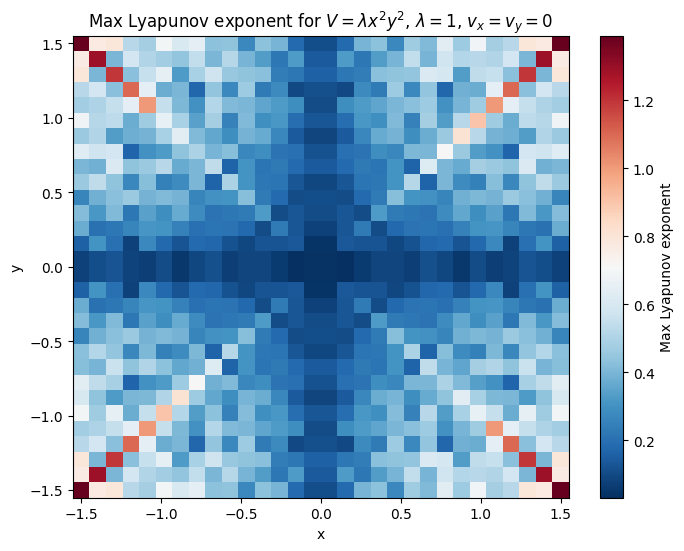

In [14]:
    lam = 1.0                     # 势能参数
    T_total = 100.0               # 积分时间（可调，权衡精度与速度）
    tau = 1.0                     # 重正交化间隔
    dt = 0.01                     # RK4 步长

    # 定义网格区域：x 和 y 的范围，固定初始速度为零
    x_vals = np.linspace(-1.5, 1.5, 30)   # 30 个点
    y_vals = np.linspace(-1.5, 1.5, 30)
    max_lyap = np.zeros((len(x_vals), len(y_vals)))

    print("开始计算 Lyapunov 指数网格...")
    for i, x0 in enumerate(x_vals):
        for j, y0 in enumerate(y_vals):
            z0 = [x0, y0, 0.0, 0.0]      # 初始速度为零
            exponents = compute_lyapunov(z0, lam, T_total, tau, dt)
            max_lyap[i, j] = exponents[0] # 最大 Lyapunov 指数
            if (i * len(y_vals) + j) % 50 == 0:
                print(f"已完成 {i*len(y_vals)+j+1}/{len(x_vals)*len(y_vals)} 个点")

    # 绘图
    plt.figure(figsize=(8,6))
    X, Y = np.meshgrid(x_vals, y_vals, indexing='ij')
    plt.pcolormesh(X, Y, max_lyap, shading='auto', cmap='RdBu_r')
    plt.colorbar(label='Max Lyapunov exponent')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(r'Max Lyapunov exponent for $V = \lambda x^2 y^2$, $\lambda=1$, $v_x=v_y=0$')
    plt.show()


## Lyapunov 指数------0.1(初始扰动矩阵按共轭顺序排列)m

    # 初始扰动矩阵按共轭顺序排列
    Q = np.array([
        [1, 0, 0, 0],   # 扰动沿 x
        [0, 1, 0, 0],   # 扰动沿 y
        [0, 0, 0, 1],   # 扰动沿 p_y
        [0, 0, 1, 0]    # 扰动沿 p_x
    ]).T  

在哈密顿系统中，相空间存在**辛结构**：每一对共轭变量 $(q_i, p_i)$ 满足特定的几何关系。如果初始扰动向量不按共轭配对顺序排列（例如随意排成 $x, p_x, y, p_y$），Gram-Schmidt 正交化会导致计算出的 Lyapunov 指数**不能精确成对**（例如 $\lambda_1$ 与 $\lambda_4$ 不互为相反数），且收敛速度变慢。

Carpintero & Muzzio 在论文中明确指出：正确的顺序应该是 **先所有坐标 $q_i$，然后所有动量 $p_i$，但动量的顺序要与坐标顺序相反**（即 $p_n, p_{n-1}, \dots, p_1$）。对于你的 4 维系统 $(x, y, p_x, p_y)$，推荐顺序为：
- 第 1 个扰动向量：沿 $x$ 方向
- 第 2 个扰动向量：沿 $y$ 方向
- 第 3 个扰动向量：沿 $p_y$ 方向（与 $y$ 配对）
- 第 4 个扰动向量：沿 $p_x$ 方向（与 $x$ 配对）

这样，经过 QR 分解后，第 1 和 4 列形成一对，第 2 和 3 列形成一对，自然得到成对的相反指数。


In [33]:
import numpy as np

def dynamics(z, lam):
    x, y, vx, vy = z
    return np.array([vx, vy, -2*lam*x*y**2, -2*lam*x**2*y])

def jacobian(z, lam):
    x, y, vx, vy = z
    J = np.zeros((4,4))
    J[0,2] = J[1,3] = 1.0
    J[2,0] = -2*lam * y**2
    J[2,1] = -4*lam * x*y
    J[3,0] = -4*lam * x*y
    J[3,1] = -2*lam * x**2
    return J

def rk4_step(F, t, y, h):
    k1 = h * F(t, y)
    k2 = h * F(t + h/2, y + k1/2)
    k3 = h * F(t + h/2, y + k2/2)
    k4 = h * F(t + h, y + k3)
    return t + h, y + (k1 + 2*k2 + 2*k3 + k4)/6

def integrate_one_step(z, Q, dt, lam):
    # 合并状态和扰动矩阵
    combined = np.concatenate([z, Q.flatten()])
    def rhs(t, y):
        z_ = y[:4]
        Q_ = y[4:].reshape(4,4)
        dz = dynamics(z_, lam)
        A = jacobian(z_, lam)
        dQ = A @ Q_
        return np.concatenate([dz, dQ.flatten()])
    t_new, y_new = rk4_step(rhs, 0, combined, dt)
    z_new = y_new[:4]
    Q_new = y_new[4:].reshape(4,4)
    return z_new, Q_new

def compute_lyapunov(z0, lam, T_total, tau, dt):
    z = np.array(z0, dtype=float)
    # 关键：初始扰动矩阵按共轭顺序排列
    Q = np.array([
        [1, 0, 0, 0],   # 扰动沿 x
        [0, 1, 0, 0],   # 扰动沿 y
        [0, 0, 0, 1],   # 扰动沿 p_y
        [0, 0, 1, 0]    # 扰动沿 p_x
    ]).T   # 4x4，每列是一个扰动向量
    sum_log = np.zeros(4)
    t = 0.0
    while t < T_total - 1e-12:
        t_end = min(t + tau, T_total)
        while t < t_end - 1e-12:
            step = min(dt, t_end - t)
            z, Q = integrate_one_step(z, Q, step, lam)
            t += step
        Q_orth, R = np.linalg.qr(Q)
        diag_R = np.abs(np.diag(R))
        # 避免 log(0)
        sum_log += np.log(np.maximum(diag_R, 1e-16))
        Q = Q_orth
    lyap = sum_log / t
    return lyap

# 示例
lam = 1.0
z0 = [1.0, 0.5, 0.0, 0.0]   # (x, y, vx, vy)
T_total = 1000.0
tau = 1.0
dt = 0.01
exponents = compute_lyapunov(z0, lam, T_total, tau, dt)
print("Lyapunov exponents:", exponents)
print("Sum:", np.sum(exponents))

Lyapunov exponents: [ 0.32677802  0.00772303 -0.00772427 -0.32677738]
Sum: -5.915394881705893e-07


## Lyapunov 指数------0.12（积分器的辛性问题）

显式 RK4 不是辛积分器，而哈密顿系统是保守系统，相空间体积守恒，显式 RK4 长时间积分会出现能量漂移，导致虚假的正 Lyapunov 指数，尤其在高能量的四角区域误差更明显。

优化方案 1：替换为辛积分器，比如蛙跳法（Verlet）、二阶 / 四阶辛 RK 方法，完美保持哈密顿系统的相体积守恒，消除能量漂移。

优化方案 2：保留 RK4 但大幅减小步长（比如 dt=0.001），或直接使用 scipy.integrate.solve_ivp 的高精度积分器（如 DOP853），设置 rtol=1e-12, atol=1e-15，降低数值误差。

--- 开始单点验证 ---
Lyapunov exponents: [ 0.29960999  0.00725408 -0.00656093 -0.30030314]
Sum of exponents: -4.163336342344337e-14
----------------------------------------
--- 开始计算 Lyapunov 指数网格 ---
已完成 1/900 个点
已完成 51/900 个点
已完成 101/900 个点
已完成 151/900 个点
已完成 201/900 个点
已完成 251/900 个点
已完成 301/900 个点
已完成 351/900 个点
已完成 401/900 个点
已完成 451/900 个点
已完成 501/900 个点
已完成 551/900 个点
已完成 601/900 个点
已完成 651/900 个点
已完成 701/900 个点
已完成 751/900 个点
已完成 801/900 个点
已完成 851/900 个点


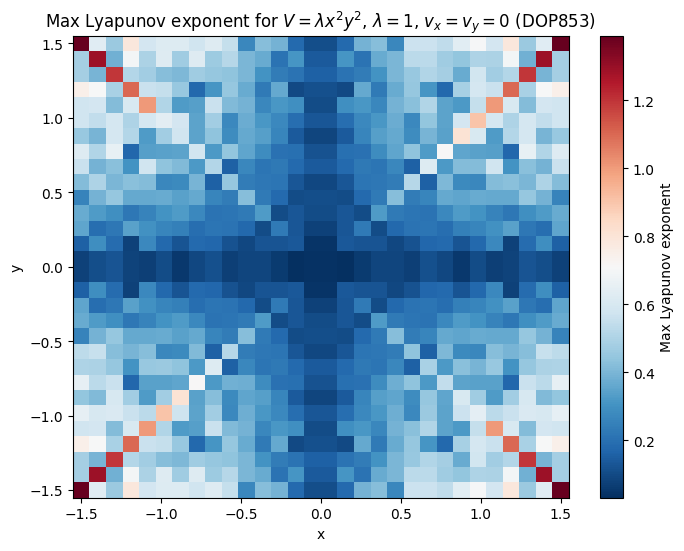

In [38]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ---------------------- 基础函数定义（保持不变） ----------------------
def dynamics(state, lam):
    """原始系统: state = [x, y, vx, vy]"""
    x, y, vx, vy = state
    dx = vx
    dy = vy
    dvx = -2 * lam * x * y**2
    dvy = -2 * lam * x**2 * y
    return np.array([dx, dy, dvx, dvy])

def jacobian(state, lam):
    """线性化矩阵 A = df/dz"""
    x, y, vx, vy = state
    J = np.zeros((4,4))
    J[0,2] = J[1,3] = 1.0
    J[2,0] = -2 * lam * y**2
    J[2,1] = -4 * lam * x * y
    J[3,0] = -4 * lam * x * y
    J[3,1] = -2 * lam * x**2
    return J

def rhs(t, combined, lam):
    z = combined[:4]
    Q_flat = combined[4:]
    Q = Q_flat.reshape((4,4))
    dzdt = dynamics(z, lam)
    A = jacobian(z, lam)
    dQdt = A @ Q
    return np.concatenate([dzdt, dQdt.flatten()])

# ---------------------- Lyapunov 指数计算（使用 solve_ivp） ----------------------
def compute_lyapunov(z0, lam, T_total, tau):
    z = np.array(z0, dtype=float)
    Q = np.eye(4)
    sum_log = np.zeros(4)
    t = 0.0

    while t < T_total - 1e-12:
        t_end = min(t + tau, T_total)
        combined = np.concatenate([z, Q.flatten()])
        
        # 使用 solve_ivp 进行高精度积分
        sol = solve_ivp(
            fun=rhs,
            t_span=(t, t_end),
            y0=combined,
            args=(lam,),
            method='DOP853',  # 高精度积分器
            rtol=1e-12,       # 相对误差容忍度
            atol=1e-15        # 绝对误差容忍度
        )
        
        # 更新状态
        combined_new = sol.y[:, -1]
        z = combined_new[:4]
        Q = combined_new[4:].reshape(4,4)
        t = t_end
        
        # QR 重正交化
        Q_orth, R = np.linalg.qr(Q)
        diag_R = np.abs(np.diag(R))
        sum_log += np.log(np.maximum(diag_R, 1e-16))
        Q = Q_orth

    return sum_log / t

# ---------------------- 第一部分：单点验证 ----------------------
print("--- 开始单点验证 ---")
lam = 1.0
z0 = [1.0, 0.5, 0.0, 0.0]
T_total = 1000.0
tau = 1.0

exponents = compute_lyapunov(z0, lam, T_total, tau)
print("Lyapunov exponents:", exponents)
print("Sum of exponents:", np.sum(exponents))
print("-" * 40)

# ---------------------- 第二部分：网格绘图 ----------------------
print("--- 开始计算 Lyapunov 指数网格 ---")
lam = 1.0
T_total = 100.0  # 绘图时为了速度可以稍微缩短，也可以保持 1000
tau = 1.0

x_vals = np.linspace(-1.5, 1.5, 30)
y_vals = np.linspace(-1.5, 1.5, 30)
max_lyap = np.zeros((len(x_vals), len(y_vals)))

for i, x0 in enumerate(x_vals):
    for j, y0 in enumerate(y_vals):
        z0 = [x0, y0, 0.0, 0.0]
        exponents = compute_lyapunov(z0, lam, T_total, tau)
        max_lyap[i, j] = exponents[0]
        if (i * len(y_vals) + j) % 50 == 0:
            print(f"已完成 {i*len(y_vals)+j+1}/{len(x_vals)*len(y_vals)} 个点")

# 绘图
plt.figure(figsize=(8,6))
X, Y = np.meshgrid(x_vals, y_vals, indexing='ij')
plt.pcolormesh(X, Y, max_lyap, shading='auto', cmap='RdBu_r')
plt.colorbar(label='Max Lyapunov exponent')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'Max Lyapunov exponent for $V = \lambda x^2 y^2$, $\lambda=1$, $v_x=v_y=0$ (DOP853)')
plt.show()

## Lyapunov 指数------0.2（协变 Lyapunov 向量CLV的计算）

1. **正向积分**： QR 分解方法，记录每一步的 $Q_{\text{orth}}$（正交矩阵）和 $R$ 的对角元（伸缩因子），并存储 $Q_{\text{orth}}$ 的历史（或者每隔一定步长存储一次）。
2. **反向积分**：从终点向回积分，利用存储的 $Q_{\text{orth}}$ 和伸缩因子，通过求解一个反向的变分方程，得到协变向量。


## 可视化

In [40]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ---------------------- 第一部分：轨迹可视化函数 ----------------------
def plot_trajectory(z0, lam, t_max=100.0, t_eval_points=10000):
    """
    绘制相空间轨迹 (x-y平面) 和时间序列图
    输入：
        z0: 初始条件 [x0, y0, vx0, vy0]
        lam: 势能参数
        t_max: 积分总时间
        t_eval_points: 采样点数
    """
    # 仅积分动力学方程（不需要变分方程，更快）
    def rhs_only_dynamics(t, z,lam):
        return dynamics(z, lam)
    
    # 高精度积分
    sol = solve_ivp(
        fun=rhs_only_dynamics,
        t_span=(0, t_max),
        y0=z0,
        args=(lam,),
        method='DOP853',
        rtol=1e-12,
        atol=1e-15,
        t_eval=np.linspace(0, t_max, t_eval_points)
    )
    
    x, y, vx, vy = sol.y
    t = sol.t
    
    # 计算能量（用于验证守恒）
    E = 0.5 * (vx**2 + vy**2) + lam * x**2 * y**2
    
    # 绘图
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. x-y 相空间轨迹
    ax[0].plot(x, y, linewidth=0.5)
    ax[0].scatter(z0[0], z0[1], c='red', s=50, zorder=5, label='Initial condition')
    ax[0].set_xlabel('x')
    ax[0].set_ylabel('y')
    ax[0].set_title(f'Trajectory in x-y plane\n$z_0$={z0}, $\lambda$={lam}')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    ax[0].axis('equal')
    
    # 2. 时间序列
    ax[1].plot(t, x, label='x(t)', linewidth=0.8)
    ax[1].plot(t, y, label='y(t)', linewidth=0.8, alpha=0.7)
    ax[1].set_xlabel('Time t')
    ax[1].set_ylabel('Position')
    ax[1].set_title('Time series of x and y')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    
    # 3. 能量守恒验证
    ax[2].plot(t, E, linewidth=1.0)
    ax[2].set_xlabel('Time t')
    ax[2].set_ylabel('Energy H')
    ax[2].set_title(f'Energy conservation check\n$\Delta E_{{max}}$ = {np.max(np.abs(E-E[0])):.2e}')
    ax[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [41]:
# ---------------------- 第二部分：Lyapunov谱随初始能量变化分析 ----------------------
def compute_lyapunov_vs_energy(lam, E_list, fixed_position=(1.0, 1.0), T_total=500.0, tau=1.0):
    """
    计算不同初始能量下的Lyapunov谱
    输入：
        lam: 势能参数
        E_list: 初始能量列表 [E1, E2, ...]
        fixed_position: 固定的初始位置 (x0, y0)，通过调整初始速度来改变能量
        T_total: 积分时间
        tau: 正交化间隔
    输出：
        max_lyap_list: 对应每个能量的最大Lyapunov指数
        all_exponents_list: 对应每个能量的完整Lyapunov谱
    """
    x0, y0 = fixed_position
    max_lyap_list = []
    all_exponents_list = []
    
    print(f"开始计算 Lyapunov 谱随能量的变化 (固定位置: ({x0}, {y0}))...")
    for i, E in enumerate(E_list):
        # 根据能量 E 反解初始速度 (假设 vx0 = vy0，对称分配动能)
        # E = 0.5*(vx0^2 + vy0^2) + lam*x0^2*y0^2
        V0 = lam * x0**2 * y0**2
        if E < V0:
            print(f"警告: 能量 E={E:.2f} 小于势能 V0={V0:.2f}，跳过 (无实数解)")
            max_lyap_list.append(np.nan)
            all_exponents_list.append([np.nan]*4)
            continue
        
        kinetic_energy = E - V0
        v0 = np.sqrt(kinetic_energy)  # 因为假设 vx0=vy0=v，所以 0.5*(v^2 + v^2) = v^2
        z0 = [x0, y0, v0, v0]
        
        # 计算Lyapunov指数
        exponents = compute_lyapunov(z0, lam, T_total, tau)
        max_lyap_list.append(exponents[0])
        all_exponents_list.append(exponents)
        
        print(f"[{i+1}/{len(E_list)}] E={E:.2f}, MLE={exponents[0]:.4f}, Sum={np.sum(exponents):.2e}")
    
    return np.array(max_lyap_list), np.array(all_exponents_list)

In [42]:
def plot_lyapunov_vs_energy(E_list, max_lyap_list, all_exponents_list, lam):
    """绘制 Lyapunov 谱随能量变化的曲线"""
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. 仅绘制最大 Lyapunov 指数
    ax[0].plot(E_list, max_lyap_list, 'o-', linewidth=1.5, markersize=4, label='Max Lyapunov exponent')
    ax[0].axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.7)
    ax[0].set_xlabel('Initial Energy $E$')
    ax[0].set_ylabel('Max Lyapunov exponent')
    ax[0].set_title(f'Max Lyapunov exponent vs. Initial Energy ($\lambda$={lam})')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    # 2. 绘制完整的 Lyapunov 谱
    colors = ['red', 'orange', 'green', 'blue']
    labels = ['$\lambda_1$ (Max)', '$\lambda_2$', '$\lambda_3$', '$\lambda_4$']
    for i in range(4):
        ax[1].plot(E_list, all_exponents_list[:, i], 'o-', linewidth=1.0, markersize=3, color=colors[i], label=labels[i])
    
    ax[1].axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.7)
    ax[1].set_xlabel('Initial Energy $E$')
    ax[1].set_ylabel('Lyapunov exponents')
    ax[1].set_title(f'Full Lyapunov spectrum vs. Initial Energy ($\lambda$={lam})')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

--- 任务 1：轨迹可视化 ---
绘制混沌运动轨迹...


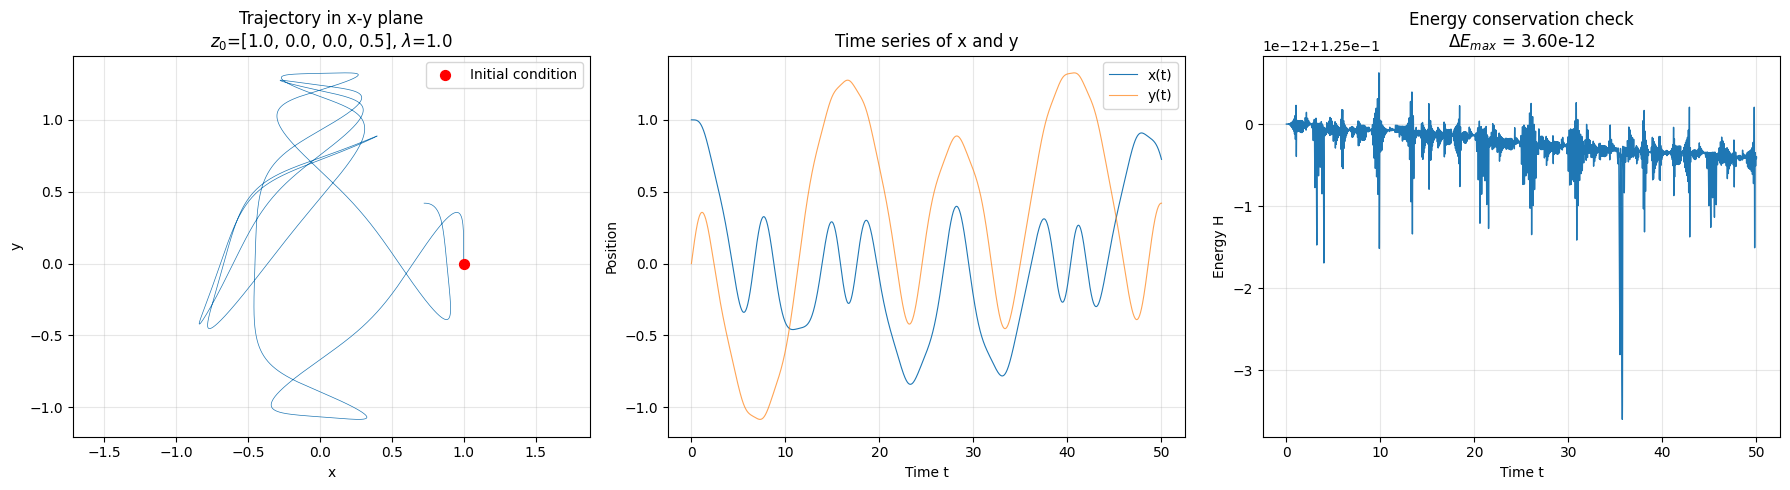

绘制规则运动轨迹...


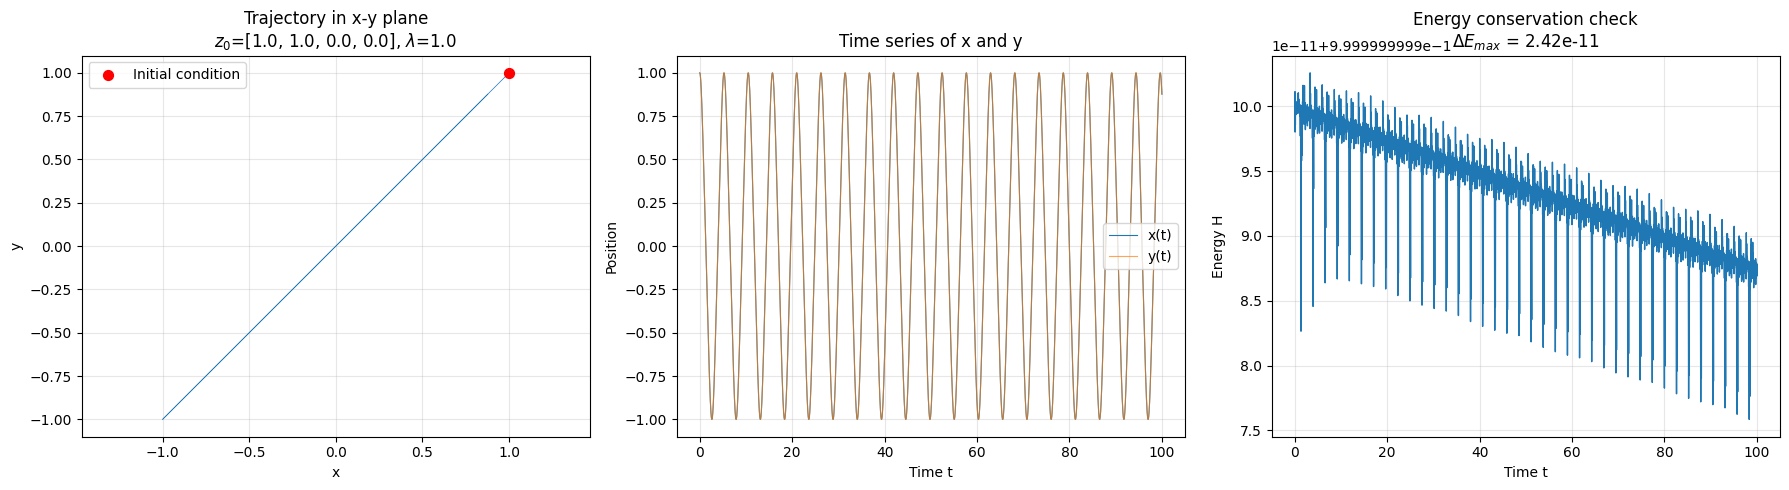


--- 任务 2：Lyapunov 谱随能量变化 ---
开始计算 Lyapunov 谱随能量的变化 (固定位置: (1.0, 1.0))...
警告: 能量 E=0.10 小于势能 V0=1.00，跳过 (无实数解)
警告: 能量 E=0.62 小于势能 V0=1.00，跳过 (无实数解)
[3/20] E=1.14, MLE=0.9582, Sum=-3.95e-14
[4/20] E=1.66, MLE=1.0530, Sum=-4.15e-14
[5/20] E=2.18, MLE=1.1268, Sum=-4.31e-14
[6/20] E=2.71, MLE=1.1895, Sum=-4.55e-14
[7/20] E=3.23, MLE=1.2432, Sum=-4.53e-14
[8/20] E=3.75, MLE=1.2906, Sum=-4.77e-14
[9/20] E=4.27, MLE=1.3326, Sum=-4.97e-14
[10/20] E=4.79, MLE=1.3716, Sum=-5.11e-14
[11/20] E=5.31, MLE=1.4084, Sum=-5.44e-14
[12/20] E=5.83, MLE=1.4416, Sum=-5.06e-14
[13/20] E=6.35, MLE=1.4725, Sum=-5.20e-14
[14/20] E=6.87, MLE=1.5017, Sum=-5.68e-14
[15/20] E=7.39, MLE=1.5300, Sum=-5.68e-14
[16/20] E=7.92, MLE=1.5555, Sum=-5.84e-14
[17/20] E=8.44, MLE=1.5802, Sum=-5.97e-14
[18/20] E=8.96, MLE=1.6042, Sum=-6.15e-14
[19/20] E=9.48, MLE=1.6280, Sum=-6.20e-14
[20/20] E=10.00, MLE=1.6490, Sum=-6.31e-14


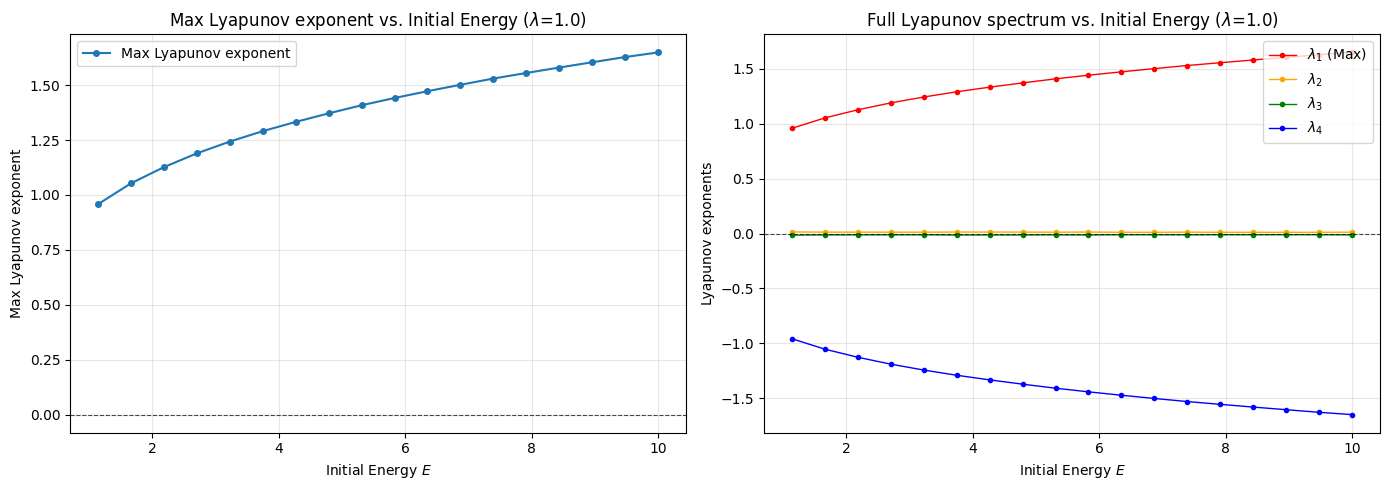

In [43]:
lam = 1.0
    
# ==========================================
# 任务 1：轨迹可视化（对比规则运动与混沌运动）
# ==========================================
print("--- 任务 1：轨迹可视化 ---")
    
# 案例 1：混沌运动（y0=0，但有初始速度，打破对称性）
print("绘制混沌运动轨迹...")
z0_chaotic = [1.0, 0.0, 0.0, 0.5]  # y0=0，在对称轴上
plot_trajectory(z0_chaotic, lam, t_max=50.0)
    
# 案例 2：规则运动（x0=y0，对称初始条件，退化为单自由度）
print("绘制规则运动轨迹...")
z0_regular = [1.0, 1.0, 0.0, 0.0]   # 高势能初始条件
plot_trajectory(z0_regular, lam, t_max=100.0)
    
# ==========================================
# 任务 2：Lyapunov 谱随初始能量变化
# ==========================================
print("\n--- 任务 2：Lyapunov 谱随能量变化 ---")
    
# 定义能量扫描范围（从略高于势能最小值开始）
E_list = np.linspace(0.1, 10.0, 20)  # 20个能量点，可根据需要调整
    
# 计算
max_lyap_list, all_exponents_list = compute_lyapunov_vs_energy(
    lam=lam,
    E_list=E_list,
    fixed_position=(1.0, 1.0),
    T_total=500.0,  # 为了速度可以设为 200，论文用建议 500-1000
    tau=1.0
)
    
# 绘图
plot_lyapunov_vs_energy(E_list, max_lyap_list, all_exponents_list, lam)

## 可视化2.0

In [45]:
# ---------------------- 更新版：轨迹可视化函数（带自动保存） ----------------------
def plot_trajectory(z0, lam, t_max=100.0, t_eval_points=10000, save_name=None):
    """
    绘制相空间轨迹 (x-y平面) 和时间序列图
    save_name: 例如 'trajectory_chaotic'，会自动保存为 trajectory_chaotic.pdf 和 trajectory_chaotic.png
    """
    # 仅积分动力学方程（不需要变分方程，更快）
    def rhs_only_dynamics(t, z, lam):
        return dynamics(z, lam)
    
    # 高精度积分
    sol = solve_ivp(
        fun=rhs_only_dynamics,
        t_span=(0, t_max),
        y0=z0,
        args=(lam,),
        method='DOP853',
        rtol=1e-12,
        atol=1e-15,
        t_eval=np.linspace(0, t_max, t_eval_points)
    )
    
    x, y, vx, vy = sol.y
    t = sol.t
    
    # 计算能量（用于验证守恒）
    E = 0.5 * (vx**2 + vy**2) + lam * x**2 * y**2
    
    # 绘图
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. x-y 相空间轨迹
    ax[0].plot(x, y, linewidth=0.5)
    ax[0].scatter(z0[0], z0[1], c='red', s=50, zorder=5, label='Initial condition')
    ax[0].set_xlabel('x')
    ax[0].set_ylabel('y')
    ax[0].set_title(f'Trajectory in x-y plane\n$z_0$={z0}, $\lambda$={lam}')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    ax[0].axis('equal')
    
    # 2. 时间序列
    ax[1].plot(t, x, label='x(t)', linewidth=0.8)
    ax[1].plot(t, y, label='y(t)', linewidth=0.8, alpha=0.7)
    ax[1].set_xlabel('Time t')
    ax[1].set_ylabel('Position')
    ax[1].set_title('Time series of x and y')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    
    # 3. 能量守恒验证
    ax[2].plot(t, E, linewidth=1.0)
    ax[2].set_xlabel('Time t')
    ax[2].set_ylabel('Energy H')
    ax[2].set_title(f'Energy conservation check\n$\Delta E_{{max}}$ = {np.max(np.abs(E-E[0])):.2e}')
    ax[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 【新增】：自动保存
    if save_name is not None:
        plt.savefig(f"{save_name}.pdf", dpi=300, bbox_inches='tight') # 保存 PDF (矢量图，适合论文)
        plt.savefig(f"{save_name}.png", dpi=300, bbox_inches='tight') # 保存 PNG (预览用)
        print(f"图片已保存为: {save_name}.pdf / .png")
    
    plt.show()

# ---------------------- 更新版：Lyapunov 谱绘图函数（带自动保存） ----------------------
def plot_lyapunov_vs_energy(E_list, max_lyap_list, all_exponents_list, lam, save_name='lyapunov_vs_energy'):
    """绘制 Lyapunov 谱随能量变化的曲线"""
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. 仅绘制最大 Lyapunov 指数
    ax[0].plot(E_list, max_lyap_list, 'o-', linewidth=1.5, markersize=4, label='Max Lyapunov exponent')
    ax[0].axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.7)
    ax[0].set_xlabel('Initial Energy $E$')
    ax[0].set_ylabel('Max Lyapunov exponent')
    ax[0].set_title(f'Max Lyapunov exponent vs. Initial Energy ($\lambda$={lam})')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    # 2. 绘制完整的 Lyapunov 谱
    colors = ['red', 'orange', 'green', 'blue']
    labels = ['$\lambda_1$ (Max)', '$\lambda_2$', '$\lambda_3$', '$\lambda_4$']
    for i in range(4):
        ax[1].plot(E_list, all_exponents_list[:, i], 'o-', linewidth=1.0, markersize=3, color=colors[i], label=labels[i])
    
    ax[1].axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.7)
    ax[1].set_xlabel('Initial Energy $E$')
    ax[1].set_ylabel('Lyapunov exponents')
    ax[1].set_title(f'Full Lyapunov spectrum vs. Initial Energy ($\lambda$={lam})')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 【新增】：自动保存
    if save_name is not None:
        plt.savefig(f"{save_name}.pdf", dpi=300, bbox_inches='tight')
        plt.savefig(f"{save_name}.png", dpi=300, bbox_inches='tight')
        print(f"图片已保存为: {save_name}.pdf / .png")
    
    plt.show()

生成规则运动轨迹图...
图片已保存为: fig_trajectory_regular.pdf / .png


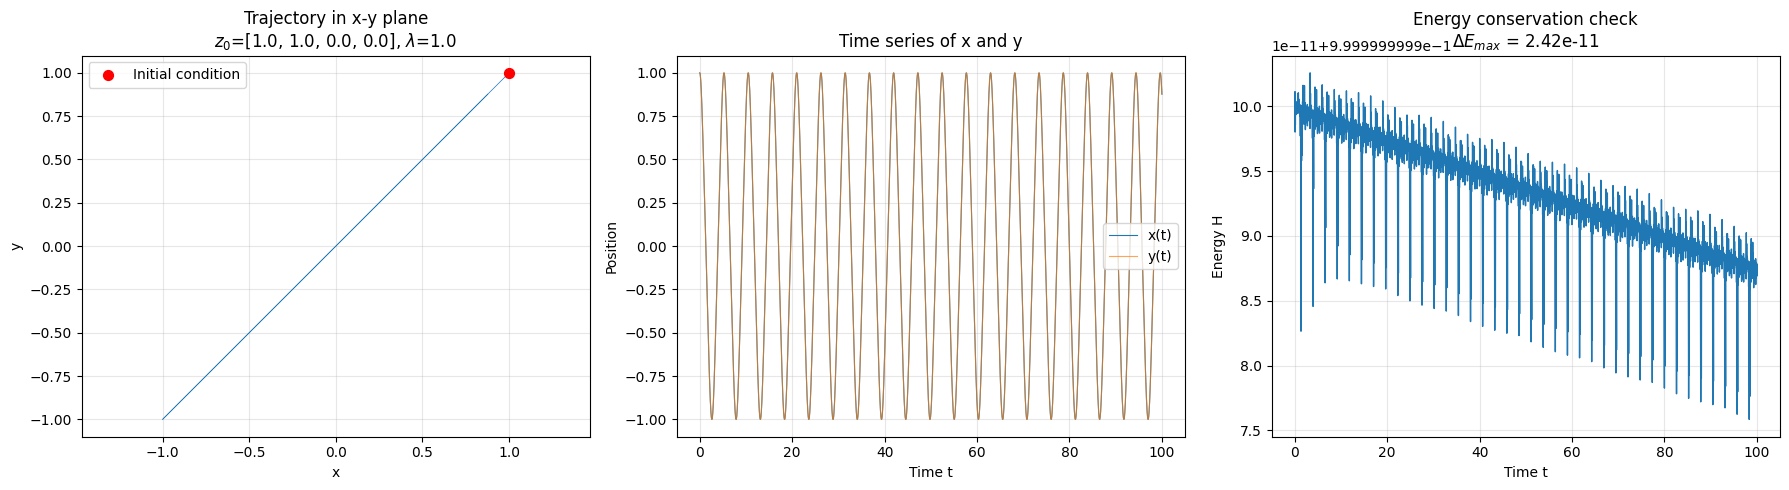

生成混沌运动轨迹图...
图片已保存为: fig_trajectory_chaotic.pdf / .png


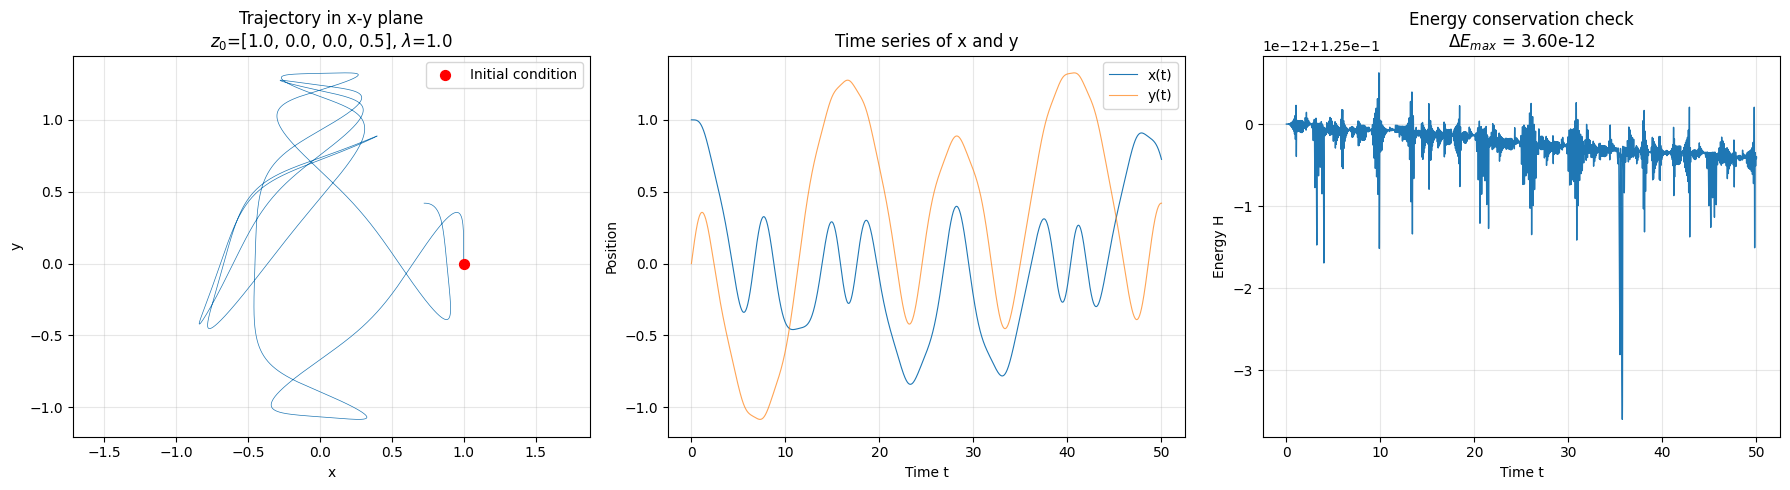

生成能量守恒验证图...


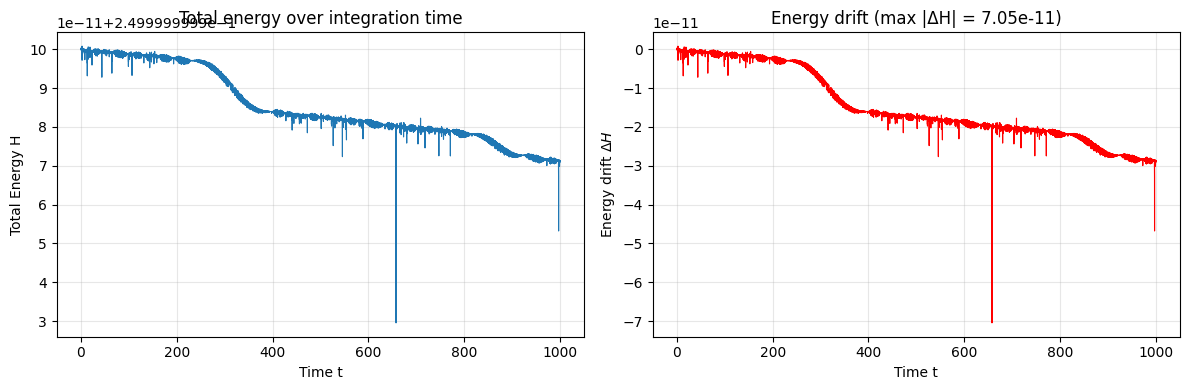

生成Lyapunov指数随能量变化图...
开始计算 Lyapunov 谱随能量的变化 (固定位置: (1.0, 1.0))...
警告: 能量 E=0.10 小于势能 V0=1.00，跳过 (无实数解)
警告: 能量 E=0.62 小于势能 V0=1.00，跳过 (无实数解)
[3/20] E=1.14, MLE=0.9582, Sum=-3.95e-14
[4/20] E=1.66, MLE=1.0530, Sum=-4.15e-14
[5/20] E=2.18, MLE=1.1268, Sum=-4.31e-14
[6/20] E=2.71, MLE=1.1895, Sum=-4.55e-14
[7/20] E=3.23, MLE=1.2432, Sum=-4.53e-14
[8/20] E=3.75, MLE=1.2906, Sum=-4.77e-14
[9/20] E=4.27, MLE=1.3326, Sum=-4.97e-14
[10/20] E=4.79, MLE=1.3716, Sum=-5.11e-14
[11/20] E=5.31, MLE=1.4084, Sum=-5.44e-14
[12/20] E=5.83, MLE=1.4416, Sum=-5.06e-14
[13/20] E=6.35, MLE=1.4725, Sum=-5.20e-14
[14/20] E=6.87, MLE=1.5017, Sum=-5.68e-14
[15/20] E=7.39, MLE=1.5300, Sum=-5.68e-14
[16/20] E=7.92, MLE=1.5555, Sum=-5.84e-14
[17/20] E=8.44, MLE=1.5802, Sum=-5.97e-14
[18/20] E=8.96, MLE=1.6042, Sum=-6.15e-14
[19/20] E=9.48, MLE=1.6280, Sum=-6.20e-14
[20/20] E=10.00, MLE=1.6490, Sum=-6.31e-14
图片已保存为: fig_lyapunov_vs_energy.pdf / .png


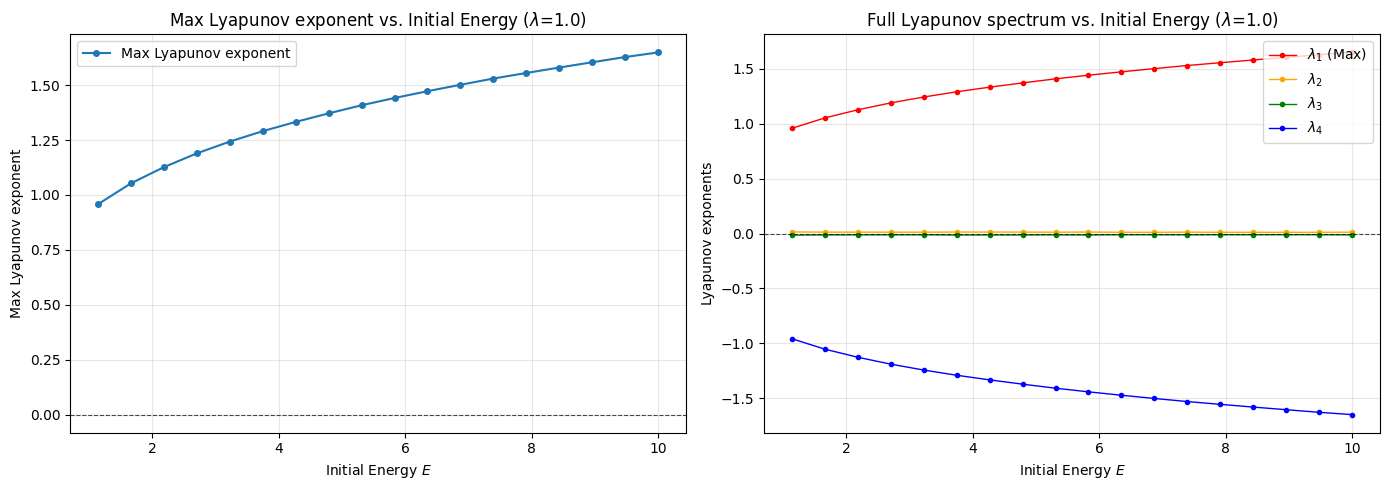

所有图片已生成并保存！


In [46]:
import numpy as np
import matplotlib.pyplot as plt

# ====================== 1. 生成规则运动+混沌运动的相空间轨迹图 ======================
lam = 1.0

# 规则运动轨迹图（论文3.2节用）
print("生成规则运动轨迹图...")
z0_regular = [1.0, 1.0, 0.0, 0.0]
plot_trajectory(z0_regular, lam, t_max=100.0, save_name='fig_trajectory_regular')

# 混沌运动轨迹图（论文3.2节用）
print("生成混沌运动轨迹图...")
z0_chaotic = [1.0, 0.0, 0.0, 0.5]
plot_trajectory(z0_chaotic, lam, t_max=50.0, save_name='fig_trajectory_chaotic')

# ====================== 2. 生成能量守恒验证图（论文3.1节用） ======================
print("生成能量守恒验证图...")
def plot_energy_conservation(z0, lam, t_max=1000.0, save_name='fig_energy_conservation'):
    """单独生成能量守恒图，用于论文算法验证"""
    def rhs_only_dynamics(t, z, lam):
        return dynamics(z, lam)
    
    # 高精度积分
    sol = solve_ivp(
        fun=rhs_only_dynamics,
        t_span=(0, t_max),
        y0=z0,
        args=(lam,),
        method='DOP853',
        rtol=1e-12,
        atol=1e-15,
        t_eval=np.linspace(0, t_max, 20000)
    )
    
    x, y, vx, vy = sol.y
    t = sol.t
    E = 0.5 * (vx**2 + vy**2) + lam * x**2 * y**2
    E0 = E[0]
    delta_E = E - E0
    
    # 绘图
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # 总能量随时间变化
    ax[0].plot(t, E, linewidth=0.8)
    ax[0].set_xlabel('Time t')
    ax[0].set_ylabel('Total Energy H')
    ax[0].set_title('Total energy over integration time')
    ax[0].grid(True, alpha=0.3)
    
    # 能量漂移量
    ax[1].plot(t, delta_E, linewidth=0.8, color='red')
    ax[1].set_xlabel('Time t')
    ax[1].set_ylabel('Energy drift $\Delta H$')
    ax[1].set_title(f'Energy drift (max |ΔH| = {np.max(np.abs(delta_E)):.2e})')
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    # 保存高清图
    plt.savefig(f"{save_name}.pdf", dpi=300, bbox_inches='tight')
    plt.savefig(f"{save_name}.png", dpi=300, bbox_inches='tight')
    plt.show()

# 调用生成（用你论文里的验证算例）
z0_verify = [1.0, 0.5, 0.0, 0.0]
plot_energy_conservation(z0_verify, lam, t_max=1000.0, save_name='fig_energy_conservation')

# ====================== 3. 生成Lyapunov指数随能量变化图（论文3.4节用） ======================
print("生成Lyapunov指数随能量变化图...")
# 定义能量扫描范围（和你之前的计算一致）
E_list = np.linspace(0.1, 10.0, 20)

# 计算（如果之前已经算过max_lyap_list和all_exponents_list，直接跳过这步，调用绘图函数即可）
max_lyap_list, all_exponents_list = compute_lyapunov_vs_energy(
    lam=lam,
    E_list=E_list,
    fixed_position=(1.0, 1.0),
    T_total=500.0,
    tau=1.0
)

# 绘图并自动保存
plot_lyapunov_vs_energy(E_list, max_lyap_list, all_exponents_list, lam, save_name='fig_lyapunov_vs_energy')

print("所有图片已生成并保存！")